In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("laptop_price.csv", encoding="latin-1")
print(df.shape) #Check data shape
print(df.head(3)) #Check the first 3 rows

(1303, 13)
   laptop_ID Company      Product   TypeName  Inches  \
0          1   Apple  MacBook Pro  Ultrabook    13.3   
1          2   Apple  Macbook Air  Ultrabook    13.3   
2          3      HP       250 G6   Notebook    15.6   

                     ScreenResolution                         Cpu  Ram  \
0  IPS Panel Retina Display 2560x1600        Intel Core i5 2.3GHz  8GB   
1                            1440x900        Intel Core i5 1.8GHz  8GB   
2                   Full HD 1920x1080  Intel Core i5 7200U 2.5GHz  8GB   

                Memory                           Gpu  OpSys  Weight  \
0            128GB SSD  Intel Iris Plus Graphics 640  macOS  1.37kg   
1  128GB Flash Storage        Intel HD Graphics 6000  macOS  1.34kg   
2            256GB SSD         Intel HD Graphics 620  No OS  1.86kg   

   Price_euros  
0      1339.69  
1       898.94  
2       575.00  


In [ ]:
print(df.info()) #Check data info
print("\n")
print(df.describe()) #Check data statistics

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB
None


         laptop_ID       Inches  Price_euros
count  1303.000000  1303.000000  1303.000000
mean    660.155794    15.017191  1123.686

In [ ]:
print(df.isnull().sum()) #Check for missing values

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [7]:
print(df["Company"].value_counts()) #Check for unique values in "Company" column, and number of times it appears

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64


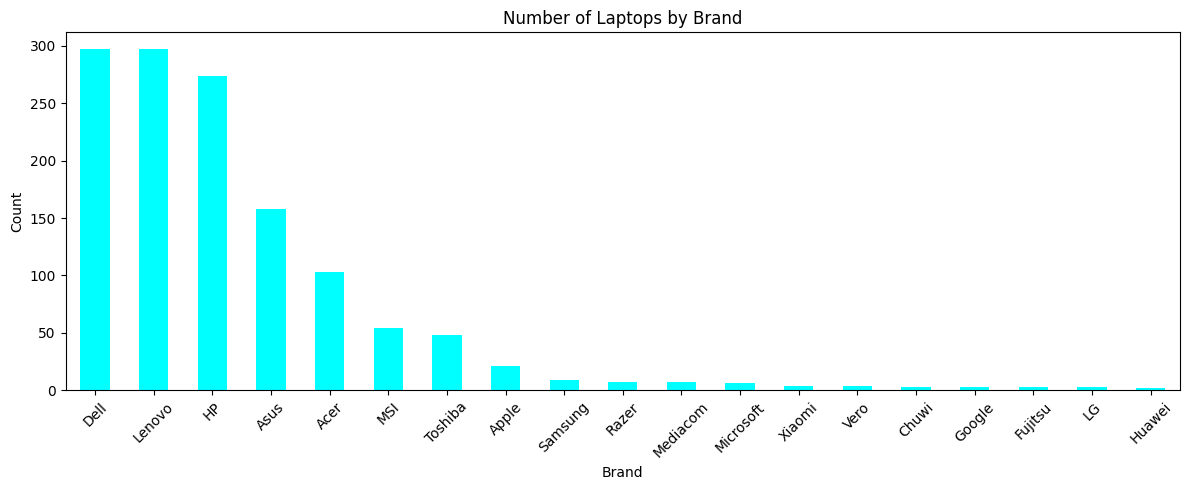

In [8]:
plt.figure(figsize=(12,5))
df["Company"].value_counts().plot(kind="bar", color="cyan")
plt.title("Number of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45) #Rotate x-axis label for better readability
plt.tight_layout() #Adjust layout to prevent overlap
plt.show() 

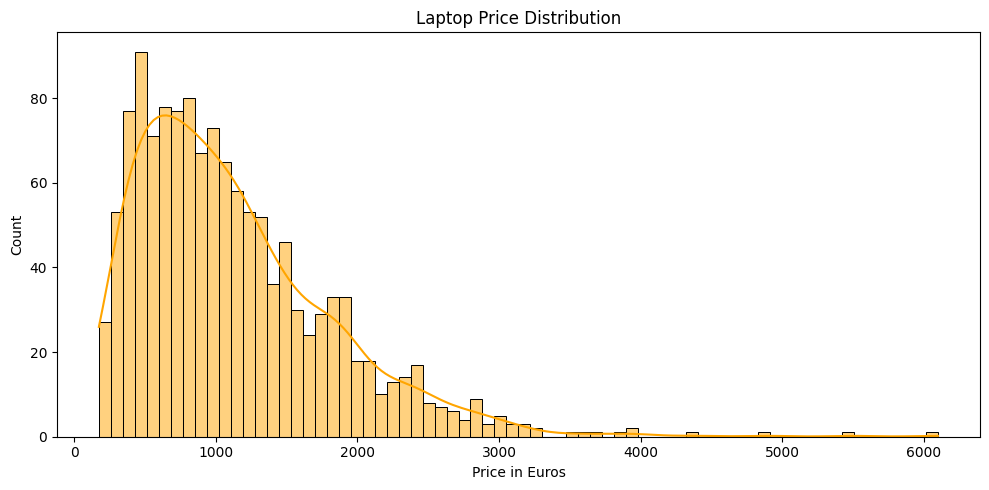

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price_euros"], bins=70, kde=True, color="orange") #bins for granularity/detail, kde=True to show density curve
plt.title("Laptop Price Distribution")
plt.xlabel("Price in Euros")
plt.tight_layout()
plt.show()

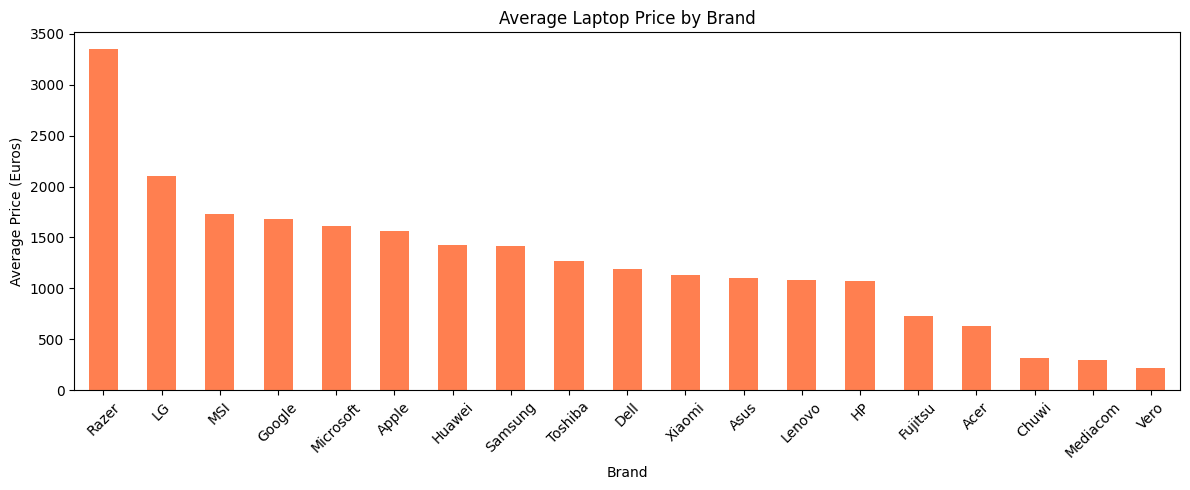

In [16]:
avg_price = df.groupby("Company")["Price_euros"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
avg_price.plot(kind="bar", color="coral")
plt.title("Average Laptop Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (Euros)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
df["Ram"] = df["Ram"].str.replace("GB","").astype(int) #Remove "GB" and convert to integer

df["Weight"] = df["Weight"].str.replace("kg","").astype(float) #Remove "kg" and convert to float because has decimal values

print(df[["Ram", "Weight"]].head())
print(df[["Ram", "Weight"]].dtypes)

   Ram  Weight
0    8    1.37
1    8    1.34
2    8    1.86
3   16    1.83
4    8    1.37
Ram         int64
Weight    float64
dtype: object


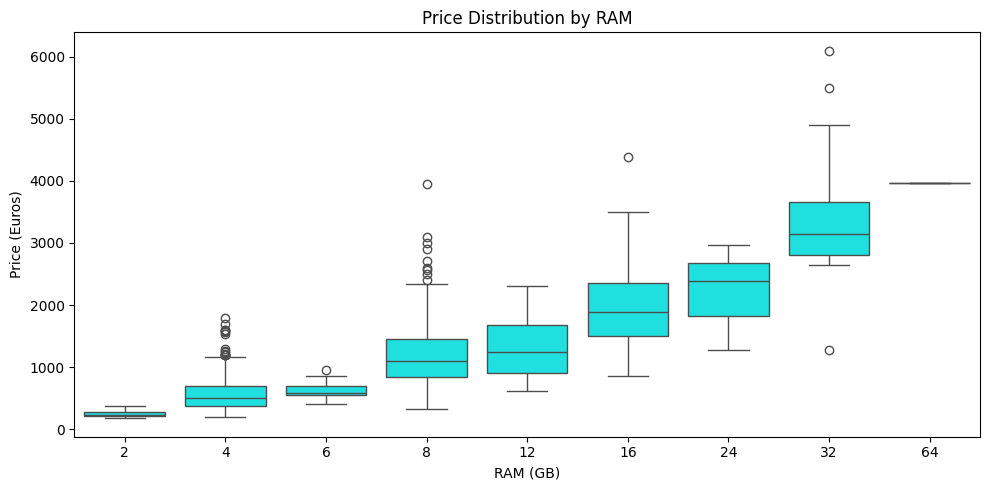

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Ram", y="Price_euros", data=df, color="cyan") #data=df to specify the DataFrame
plt.title("Price Distribution by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

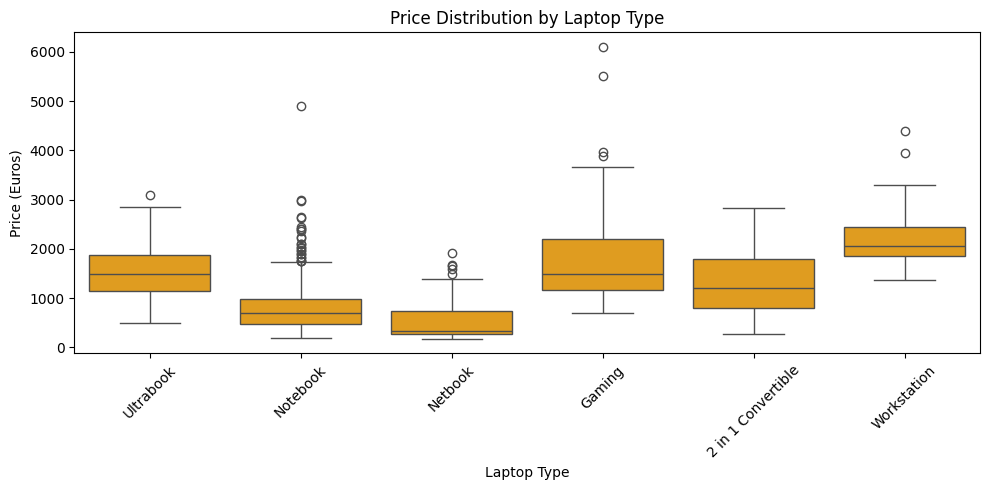

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x="TypeName", y="Price_euros", data=df, color="orange")
plt.title("Price Distribution by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Price (Euros)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

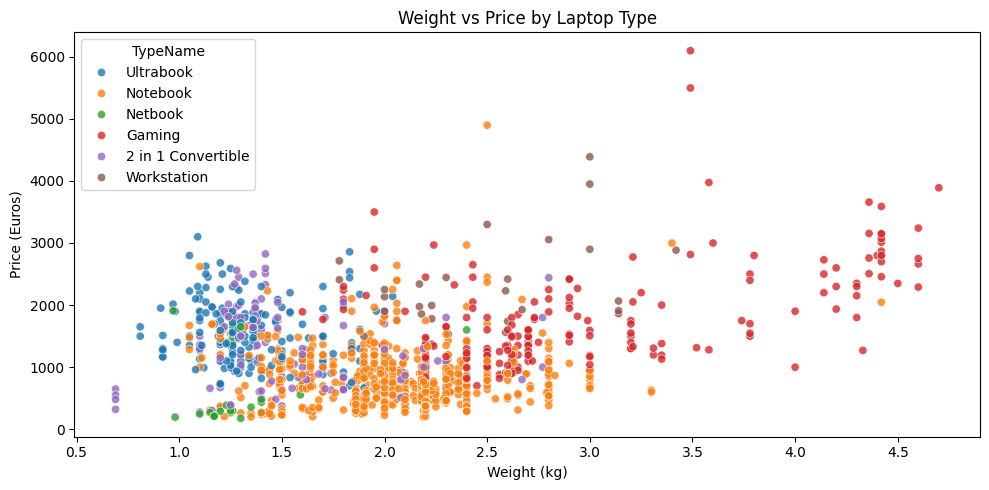

In [22]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Weight", y="Price_euros", hue="TypeName", data=df, alpha=0.8) #alpha for transparency
plt.title("Weight vs Price by Laptop Type")
plt.xlabel("Weight (kg)")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

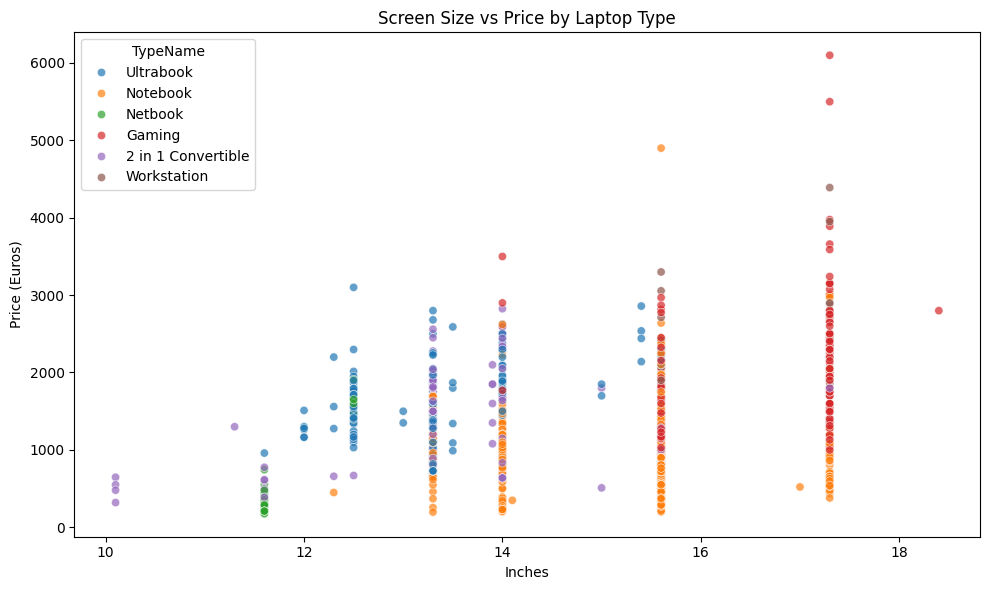

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Inches", y="Price_euros", hue="TypeName", data=df, alpha=0.7)
plt.title("Screen Size vs Price by Laptop Type")
plt.xlabel("Inches")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

In [24]:
big_screen = df[df["Inches"] > 18]
print(big_screen[["Company", "TypeName", "Inches", "Price_euros"]])

    Company TypeName  Inches  Price_euros
177     MSI   Gaming    18.4       2799.0


In [ ]:
summary = df.groupby("Company").agg( #aggregate multiple statistics
    avg_price=("Price_euros", "mean"),
    avg_ram=("Ram", "mean"),
    avg_weight=("Weight", "mean"),
    count=("Product", "count")
).round(2).sort_values("avg_price", ascending=False)

print(summary)

           avg_price  avg_ram  avg_weight  count
Company                                         
Razer        3346.14    19.43        2.20      7
LG           2099.00    10.67        1.05      3
MSI          1728.91    13.04        2.66     54
Google       1677.67    10.67        1.10      3
Microsoft    1612.31     8.00        1.25      6
Apple        1564.20     9.33        1.32     21
Huawei       1424.00     8.00        1.05      2
Samsung      1413.44    10.67        1.32      9
Toshiba      1267.81     8.67        1.64     48
Dell         1186.07     9.15        2.15    297
Xiaomi       1133.46    10.00        1.62      4
Asus         1104.17     9.59        2.22    158
Lenovo       1086.38     8.04        2.00    297
HP           1067.77     6.91        1.91    274
Fujitsu       729.00     6.67        2.23      3
Acer          626.78     5.98        2.17    103
Chuwi         314.30     4.67        1.73      3
Mediacom      295.00     3.71        1.34      7
Vero          217.42

#Laptop Price Analysis
Exploratory data analysis of 1303 laptops across 19 brand.

##Key Findings
- Razer is the most expensive brand on average
- RAM strongly correlates with price
- Gaming laptops are the most expensive category
- Most laptops are priced under 2000 euros, with a long tail of premium devices
- Outlier: MSI 18.4" gaming laptop at 2799 euros.